<a href="https://colab.research.google.com/github/Pheonix1795/MDS_LAB/blob/main/MDS_WEEK7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Analysis and Predictive Modeling: Loan Dataset
This section covers data loading, vectorized string operations, and model development for the initial loan dataset.

In [1]:
import pandas as pd

# Load the CSV file into a Pandas DataFrame
file_path = '/content/sample_data/train_u6lujuX_CVtuZ9i (1).csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded data from {file_path}.")

Successfully loaded data from /content/sample_data/train_u6lujuX_CVtuZ9i (1).csv.


In [2]:
# Display the first 5 rows of the DataFrame to inspect the data
display(df.head())

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Part A: Vectorized String Operations
Demonstrating efficient string manipulation on Pandas Series.

Now that the data is loaded, let's look for a suitable column to perform vectorized string operations. Based on the column names, 'Education' or 'Self_Employed' might be good candidates if they contain string data. If not, I'll demonstrate on 'Gender' or 'Property_Area'.

In [3]:
# Let's check the data types and unique values for potential string columns
print("Data types of columns:")
print(df.dtypes)

print("\nUnique values in 'Gender' column:")
print(df['Gender'].unique())

print("\nUnique values in 'Education' column:")
print(df['Education'].unique())

print("\nUnique values in 'Self_Employed' column:")
print(df['Self_Employed'].unique())

print("\nUnique values in 'Property_Area' column:")
print(df['Property_Area'].unique())

Data types of columns:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Unique values in 'Gender' column:
['Male' 'Female' nan]

Unique values in 'Education' column:
['Graduate' 'Not Graduate']

Unique values in 'Self_Employed' column:
['No' 'Yes' nan]

Unique values in 'Property_Area' column:
['Urban' 'Rural' 'Semiurban']


It looks like 'Education', 'Self_Employed', 'Gender', and 'Property_Area' are good candidates for string operations. Let's perform some common vectorized string operations on the 'Education' column, as an example.

In [5]:
# Perform vectorized string operations on the 'Education' column

# 1. Convert to uppercase
df['Education_Upper'] = df['Education'].str.upper()
print("\nEducation (Uppercase):")
display(df[['Education', 'Education_Upper']].head())

# 2. Check if a substring is present
df['Is_Graduate'] = df['Education'].str.contains('Graduate', na=False)
print("\nIs Graduate (contains 'Graduate'):")
display(df[['Education', 'Is_Graduate']].head())

# 3. Replace a substring
# Fixed: Removed 'na=False' which is not a valid argument for str.replace()
df['Education_Replaced'] = df['Education'].str.replace('Not Graduate', 'Non-Grad')
print("\nEducation (Replaced 'Not Graduate'):")
display(df[['Education', 'Education_Replaced']].head())

# 4. Get string length
df['Education_Length'] = df['Education'].str.len()
print("\nEducation Length:")
display(df[['Education', 'Education_Length']].head())


Education (Uppercase):


,Education,Education_Upper
0,Graduate,GRADUATE
1,Graduate,GRADUATE
2,Graduate,GRADUATE
3,Not Graduate,NOT GRADUATE
4,Graduate,GRADUATE



Is Graduate (contains 'Graduate'):


,Education,Is_Graduate
0,Graduate,True
1,Graduate,True
2,Graduate,True
3,Not Graduate,True
4,Graduate,True



Education (Replaced 'Not Graduate'):


,Education,Education_Replaced
0,Graduate,Graduate
1,Graduate,Graduate
2,Graduate,Graduate
3,Not Graduate,Non-Grad
4,Graduate,Graduate



Education Length:


,Education,Education_Length
0,Graduate,8
1,Graduate,8
2,Graduate,8
3,Not Graduate,12
4,Graduate,8


## Part B: Regularized Linear Regression
Implementing Ridge regression to predict the `LoanAmount`.

### 2. Implement Regularized Linear Regression
We will use `Ridge` regression (L2 regularization) to predict the `LoanAmount`. We'll first need to handle missing values and encode categorical variables.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Simple preprocessing for Linear Regression
reg_df = df.copy()
# Fill missing numeric values with median
reg_df['LoanAmount'] = reg_df['LoanAmount'].fillna(reg_df['LoanAmount'].median())
reg_df['Loan_Amount_Term'] = reg_df['Loan_Amount_Term'].fillna(reg_df['Loan_Amount_Term'].median())
reg_df['Credit_History'] = reg_df['Credit_History'].fillna(reg_df['Credit_History'].mode()[0])

# Selecting features for regression
X_reg = reg_df[['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']]
y_reg = reg_df['LoanAmount']

# Split and Scale
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

# Ridge Regression (L2 Regularization)
ridge_mod = Ridge(alpha=1.0)
ridge_mod.fit(X_train_reg, y_train_reg)
y_pred_reg = ridge_mod.predict(X_test_reg)

print(f"Ridge Regression MSE: {mean_squared_error(y_test_reg, y_pred_reg):.2f}")

Ridge Regression MSE: 2618.48


## Part C: Logistic Regression Model
Developing a classification model to predict `Loan_Status`.

### 3. Logistic Regression for Prediction
Now, I will develop a Logistic Regression model to predict `Loan_Status` (Target variable).

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for Logistic Regression
log_df = df.copy()
# Drop ID and fill missing target if any
log_df = log_df.dropna(subset=['Loan_Status'])

# Simple encoding: Convert Target to binary
log_df['Loan_Status'] = log_df['Loan_Status'].map({'Y': 1, 'N': 0})

# Fill other missing values with mode
for col in log_df.columns:
    if log_df[col].dtype == 'object':
        log_df[col] = log_df[col].fillna(log_df[col].mode()[0])
    else:
        log_df[col] = log_df[col].fillna(log_df[col].median())

# Convert categorical features to dummy variables
X_log = pd.get_dummies(log_df.drop(['Loan_ID', 'Loan_Status'], axis=1), drop_first=True)
y_log = log_df['Loan_Status']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

# Develop Logistic Regression Model
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train_log, y_train_log)

y_pred_log = log_model.predict(X_test_log)

print("Logistic Regression Accuracy:", accuracy_score(y_test_log, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test_log, y_pred_log))

Logistic Regression Accuracy: 0.7886178861788617

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Analysis on Heart Disease Dataset
This section repeats the previous tasks using `/content/sample_data/heart.csv`.

# 2. Comparative Analysis: Heart Disease Dataset
Repeating the operations on the heart disease dataset for comparative study.

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

# 1. Load the Heart dataset
heart_df = pd.read_csv('/content/sample_data/heart.csv')
display(heart_df.head())

# 1(a). Perform Vectorized String operations
# Note: Heart.csv is typically numeric. We will create a string column to demonstrate operations.
heart_df['Sex_Str'] = heart_df['sex'].map({1: 'male', 0: 'female'})

print("Vectorized String Operations on 'Sex_Str':")
# Uppercase
heart_df['Sex_Upper'] = heart_df['Sex_Str'].str.upper()
# Length
heart_df['Sex_Len'] = heart_df['Sex_Str'].str.len()
# Contains substring
heart_df['Is_Male'] = heart_df['Sex_Str'].str.contains('male')

display(heart_df[['Sex_Str', 'Sex_Upper', 'Sex_Len', 'Is_Male']].head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Vectorized String Operations on 'Sex_Str':


,Sex_Str,Sex_Upper,Sex_Len,Is_Male
0,male,MALE,4,True
1,male,MALE,4,True
2,male,MALE,4,True
3,male,MALE,4,True
4,female,FEMALE,6,True


## Part A: String Operations (Heart Dataset)

In [9]:
# 2. Implement Regularized Linear Regression
# Predicting 'trestbps' (resting blood pressure) as a continuous target
X_reg = heart_df.drop(['trestbps', 'Sex_Str', 'Sex_Upper', 'Is_Male'], axis=1)
y_reg = heart_df['trestbps']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
preds_reg = ridge.predict(X_test_scaled)

print(f"Regularized (Ridge) Linear Regression MSE: {mean_squared_error(y_test, preds_reg):.2f}")

Regularized (Ridge) Linear Regression MSE: 255.39


## Part B: Regularized Linear Regression (Heart Dataset)

In [10]:
# 3. Develop Logistic Regression model
# Predicting 'target' (presence of heart disease)
X_log = heart_df.drop(['target', 'Sex_Str', 'Sex_Upper', 'Is_Male'], axis=1)
y_log = heart_df['target']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_l, y_train_l)
preds_log = log_reg.predict(X_test_l)

print("Logistic Regression Accuracy:", accuracy_score(y_test_l, preds_log))
print("\nClassification Report:\n", classification_report(y_test_l, preds_log))

Logistic Regression Accuracy: 0.7951219512195122

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



## Part C: Logistic Regression Model (Heart Dataset)

### 3(e). Logistic Regression Model for Heart Disease Prediction
In this section, we build a classification model to predict the `target` variable (presence of heart disease) using the features provided in the dataset.

Model Accuracy: 79.51%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



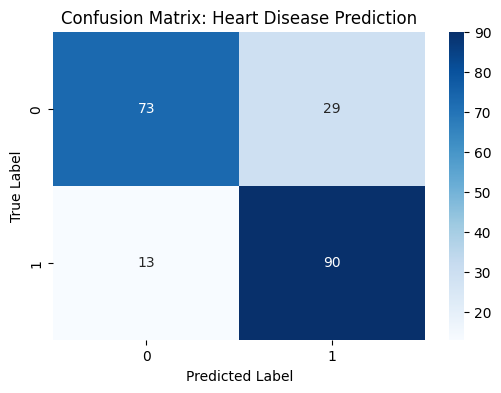

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Features and Target
# We exclude the string columns we created earlier for demonstration
X = heart_df.drop(['target', 'Sex_Str', 'Sex_Upper', 'Sex_Len', 'Is_Male'], axis=1)
y = heart_df['target']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features (important for Logistic Regression convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and Train the Model
log_model = LogisticRegression(solver='liblinear')
log_model.fit(X_train_scaled, y_train)

# 5. Make Predictions
y_pred = log_model.predict(X_test_scaled)

# 6. Evaluate the Model
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 7. Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Heart Disease Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()